In [30]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.covariance import LedoitWolf

# ~~~~~~~~~~~~~~~~~~

def cosine_matrices(E):
    return E @ E.transpose(0, 2, 1)

def cluster_labels(E, tau=0.85):
    clusters = []

    for X in E:
        model = AgglomerativeClustering(
            metric="cosine",
            linkage="average",
            distance_threshold=1 - tau,
            n_clusters=None,
        )
        clusters.append(model.fit_predict(X))

    return clusters

# ~~~~~~~~~~~~~~~~~~~

def pairwise_geometry_features(E, S):
    n_q, n_resp, _ = E.shape
    iu = np.triu_indices(n_resp, k=1)

    mean_pairwise_cosdist = np.empty(n_q)
    var_pairwise_cossim = np.empty(n_q)
    mean_centroid_cosdist = np.empty(n_q)
    var_centroid_cosdist = np.empty(n_q)

    for i in range(n_q):
        sims = S[i][iu]
        dists = 1 - sims

        mean_pairwise_cosdist[i] = dists.mean()
        var_pairwise_cossim[i] = sims.var()

        X = E[i]
        c = X.mean(axis=0)
        c = c / np.linalg.norm(c)

        cdist = 1 - (X @ c)
        mean_centroid_cosdist[i] = cdist.mean()
        var_centroid_cosdist[i] = cdist.var()

    return pd.DataFrame({
        "mean_pairwise_cosdist": mean_pairwise_cosdist,
        "var_pairwise_cossim": var_pairwise_cossim,
        "mean_centroid_cosdist": mean_centroid_cosdist,
        "var_centroid_cosdist": var_centroid_cosdist,
    })

# ~~~~~~~~~~~~~~~~~~~

def cluster_structure_features(cluster_list, n_responses=20):
    K = []
    H_sem = []
    largest_cluster_frac = []
    second_largest_cluster_frac = []
    cluster_gap = []
    singleton_cluster_frac = []

    for labels in cluster_list:
        counts = np.bincount(labels)
        probs = counts / counts.sum()
        probs_sorted = np.sort(probs)[::-1]

        K.append(len(counts))
        H_sem.append(-(probs * np.log2(probs)).sum())
        largest_cluster_frac.append(probs_sorted[0])

        if len(probs_sorted) > 1:
            second = probs_sorted[1]
        else:
            second = 0.0

        second_largest_cluster_frac.append(second)
        cluster_gap.append(probs_sorted[0] - second)
        singleton_cluster_frac.append((counts == 1).sum() / n_responses)

    return pd.DataFrame({
        "K": K,
        "H_sem": H_sem,
        "largest_cluster_frac": largest_cluster_frac,
        "second_largest_cluster_frac": second_largest_cluster_frac,
        "cluster_gap": cluster_gap,
        "singleton_cluster_frac": singleton_cluster_frac,
    })

# ~~~~~~~~~~~~~~~~~~~

def spectral_graph_features(S):
    rows = []

    for Si in S:
        W = np.clip(Si, 0, None).copy()
        np.fill_diagonal(W, 0.0)

        d = W.sum(axis=1)
        L = np.diag(d) - W

        evals, evecs = np.linalg.eigh(L)

        lam2 = evals[1]
        lam3 = evals[2]
        lam3_minus_lam2 = lam3 - lam2
        sgr = lam2 / (lam3 + 1e-8)

        q = evals / evals.sum()
        q = q[q > 0]
        spectral_entropy = -(q * np.log2(q)).sum()

        v2 = evecs[:, 1]
        ipr_fiedler = np.sum(v2 ** 4)

        p = np.abs(v2)
        p = p / p.sum()
        p = p[p > 0]
        fiedler_entropy = -(p * np.log2(p)).sum()
        hfer = lam2 * fiedler_entropy

        rows.append({
            "lam2": lam2,
            "lam3": lam3,
            "lam3_minus_lam2": lam3_minus_lam2,
            "SGR": sgr,
            "spectral_entropy": spectral_entropy,
            "ipr_fiedler": ipr_fiedler,
            "HFER": hfer,
        })

    return pd.DataFrame(rows)

# ~~~~~~~~~~~~~~~~~~~

def mahalanobis_features(E_grouped, mu_ref, Sigma_inv):
    diffs = E_grouped - mu_ref
    qf = np.einsum("nkd,dd,nkd->nk", diffs, Sigma_inv, diffs)
    qf = np.maximum(qf, 0.0)
    dists = np.sqrt(qf)

    return pd.DataFrame({
        "Mbar": dists.mean(axis=1),
        "Mvar": dists.var(axis=1),
        "Mmax": dists.max(axis=1),
    })

In [31]:
df = pd.read_json("aggregated_dataset_clean.jsonl",lines=True)
E = np.load("aggregated_response_embeddings.npy")

df = df.copy()
df["embedding"] = list(E)

grouped = (
    df.groupby(["dataset", "q_id"], sort=False)
      .agg(
          embeddings=("embedding", list)
      )
      .reset_index()
)

E_grouped = np.stack(grouped["embeddings"].apply(np.array).to_list())
q_ids = grouped["q_id"].to_numpy()
datasets = grouped["dataset"].to_numpy()

S = cosine_matrices(E_grouped)
clusters = cluster_labels(E_grouped, tau=0.85)

In [32]:
geom_df = pairwise_geometry_features(E_grouped, S)
geom_df.head()

,mean_pairwise_cosdist,var_pairwise_cossim,mean_centroid_cosdist,var_centroid_cosdist
0,0.408456,0.045926,0.217717,0.017053
1,0.508746,0.073850,0.281187,0.024592
2,0.593055,0.026550,0.339244,0.012629
3,0.194919,0.041397,0.097322,0.015608
4,0.546523,0.037540,0.306600,0.012053


In [33]:
cluster_df = cluster_structure_features(clusters, n_responses=E_grouped.shape[1])
cluster_df.head()

,K,H_sem,largest_cluster_frac,second_largest_cluster_frac,cluster_gap,singleton_cluster_frac
0,11,3.001609,0.35,0.15,0.20,0.40
1,11,2.921928,0.40,0.10,0.30,0.40
2,18,4.121928,0.10,0.10,0.00,0.80
3,3,1.076298,0.70,0.25,0.45,0.05
4,14,3.446439,0.30,0.10,0.20,0.60


In [34]:
spectral_df = spectral_graph_features(S)
spectral_df.head()

,lam2,lam3,lam3_minus_lam2,SGR,spectral_entropy,ipr_fiedler,HFER
0,7.610835,8.899894,1.289059,0.855160,4.220467,0.115052,27.738949
1,4.333150,5.990732,1.657582,0.723309,4.192606,0.159055,17.826683
2,4.783460,5.383791,0.600331,0.888493,4.215498,0.488723,16.817379
3,7.624615,12.789748,5.165133,0.596151,4.228067,0.890134,23.464785
4,5.536157,6.727591,1.191433,0.822903,4.219021,0.205027,20.219067


In [35]:
mask_correct = (df["label"] == 0).to_numpy() 
E_ref = E[mask_correct]                  

mu_ref = E_ref.mean(axis=0)
lw = LedoitWolf().fit(E_ref)
Sigma_inv = lw.precision_

mahal_df = mahalanobis_features(E_grouped, mu_ref, Sigma_inv)
mahal_df.head()

,Mbar,Mvar,Mmax
0,45.324028,10.187979,52.026024
1,47.704170,11.179836,51.525455
2,50.154140,1.555312,52.538879
3,44.024326,3.763488,51.049717
4,46.997215,2.336646,50.222157


In [55]:
X.columns

Index(['dataset', 'q_id', 'mean_pairwise_cosdist', 'var_pairwise_cossim',
       'mean_centroid_cosdist', 'var_centroid_cosdist', 'K', 'H_sem',
       'largest_cluster_frac', 'second_largest_cluster_frac', 'cluster_gap',
       'singleton_cluster_frac', 'lam2', 'lam3', 'lam3_minus_lam2', 'SGR',
       'spectral_entropy', 'ipr_fiedler', 'HFER', 'Mbar', 'Mvar', 'Mmax',
       'p_hat', 'y'],
      dtype='str')

In [36]:
X = pd.concat(
    [geom_df, cluster_df, spectral_df, mahal_df],
    axis=1
)

X.insert(0, "q_id", q_ids)
X.insert(0, "dataset", datasets)

In [37]:
question_stats = pd.read_csv("question_stats.csv")

X = X.merge(
    question_stats,
    on=["dataset", "q_id"],
    how="inner"
)

In [40]:
X.isna().sum().sort_values(ascending=False)

dataset                        0
q_id                           0
mean_pairwise_cosdist          0
var_pairwise_cossim            0
mean_centroid_cosdist          0
var_centroid_cosdist           0
K                              0
H_sem                          0
largest_cluster_frac           0
second_largest_cluster_frac    0
cluster_gap                    0
singleton_cluster_frac         0
lam2                           0
lam3                           0
lam3_minus_lam2                0
SGR                            0
spectral_entropy               0
ipr_fiedler                    0
HFER                           0
Mbar                           0
Mvar                           0
Mmax                           0
p_hat                          0
y                              0
dtype: int64

In [41]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_pairwise_cosdist,2500.0,0.337054,0.232238,-4.768372e-07,0.119210,0.345622,0.521006,0.865295
var_pairwise_cossim,2500.0,0.041236,0.034779,0.000000e+00,0.014187,0.035252,0.059650,0.252296
mean_centroid_cosdist,2500.0,0.187359,0.139359,-2.384186e-07,0.058325,0.180452,0.289335,0.578135
var_centroid_cosdist,2500.0,0.017394,0.016815,0.000000e+00,0.004238,0.012791,0.026002,0.136888
K,2500.0,9.111600,6.577633,1.000000e+00,3.000000,8.000000,15.000000,20.000000
H_sem,2500.0,2.250397,1.554644,-0.000000e+00,0.747585,2.419241,3.784184,4.321928
largest_cluster_frac,2500.0,0.495780,0.340616,5.000000e-02,0.150000,0.450000,0.850000,1.000000
second_largest_cluster_frac,2500.0,0.111500,0.091105,0.000000e+00,0.050000,0.100000,0.150000,0.500000
cluster_gap,2500.0,0.384280,0.375011,0.000000e+00,0.050000,0.250000,0.750000,1.000000
singleton_cluster_frac,2500.0,0.352880,0.327497,0.000000e+00,0.050000,0.250000,0.650000,1.000000


In [42]:
X.corr(numeric_only=True)["p_hat"].sort_values()

largest_cluster_frac          -0.690703
cluster_gap                   -0.669365
lam3                          -0.625986
lam2                          -0.589189
HFER                          -0.576853
spectral_entropy              -0.362410
SGR                           -0.191570
lam3_minus_lam2               -0.048208
ipr_fiedler                    0.082382
second_largest_cluster_frac    0.172924
var_centroid_cosdist           0.218958
var_pairwise_cossim            0.223981
Mvar                           0.305097
Mbar                           0.357927
Mmax                           0.478962
singleton_cluster_frac         0.615154
K                              0.660257
mean_centroid_cosdist          0.668081
mean_pairwise_cosdist          0.684443
H_sem                          0.695414
y                              0.928713
p_hat                          1.000000
Name: p_hat, dtype: float64

In [43]:
X.corr(numeric_only=True)["y"].sort_values()

largest_cluster_frac          -0.661640
cluster_gap                   -0.635589
lam3                          -0.553850
lam2                          -0.519489
HFER                          -0.510346
spectral_entropy              -0.297401
SGR                           -0.166844
lam3_minus_lam2               -0.047000
ipr_fiedler                    0.086277
second_largest_cluster_frac    0.142557
var_centroid_cosdist           0.148034
var_pairwise_cossim            0.148775
Mvar                           0.270168
Mbar                           0.367653
Mmax                           0.457180
singleton_cluster_frac         0.597331
mean_centroid_cosdist          0.614762
mean_pairwise_cosdist          0.629196
K                              0.637425
H_sem                          0.664024
p_hat                          0.928713
y                              1.000000
Name: y, dtype: float64

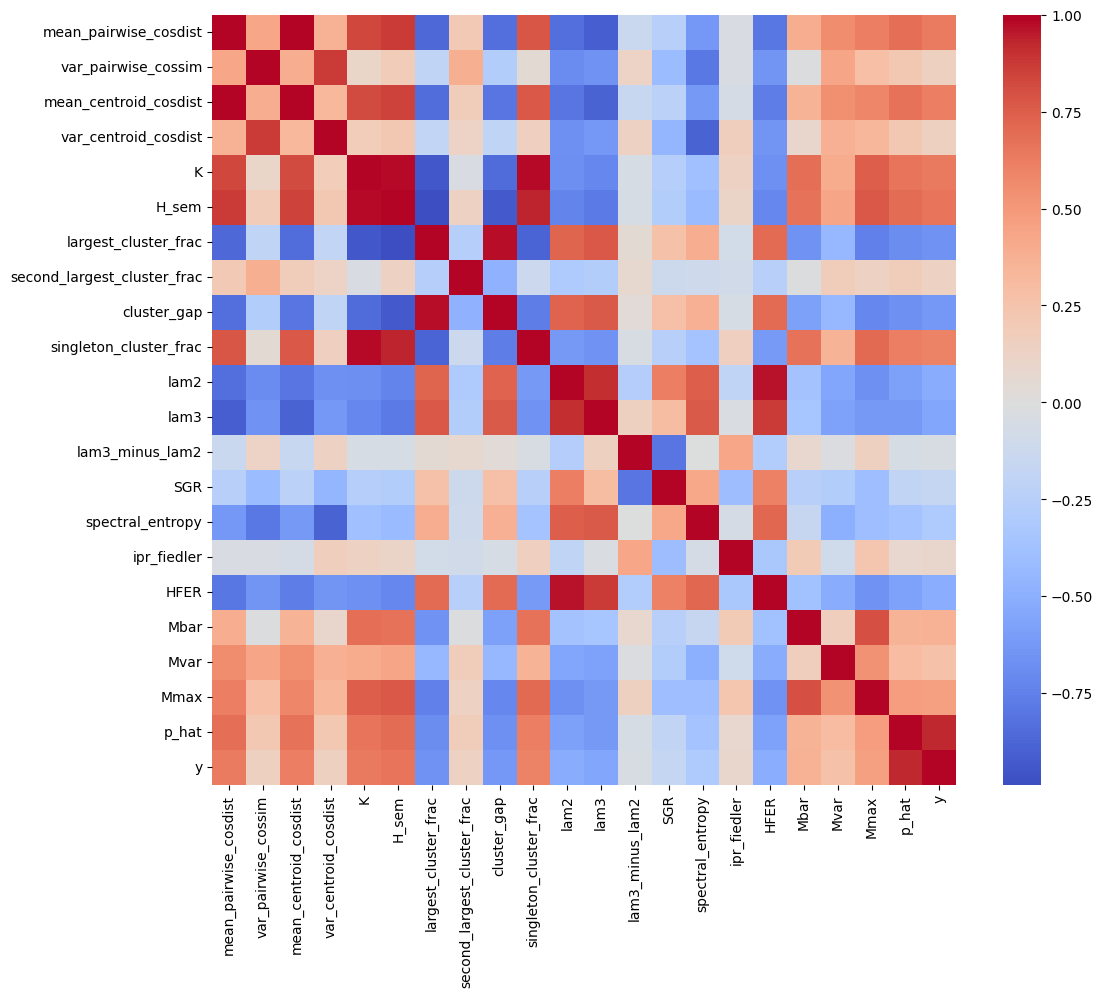

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(X.drop(columns=["q_id", "dataset"]).corr(numeric_only=True), cmap="coolwarm", center=0)
plt.show()

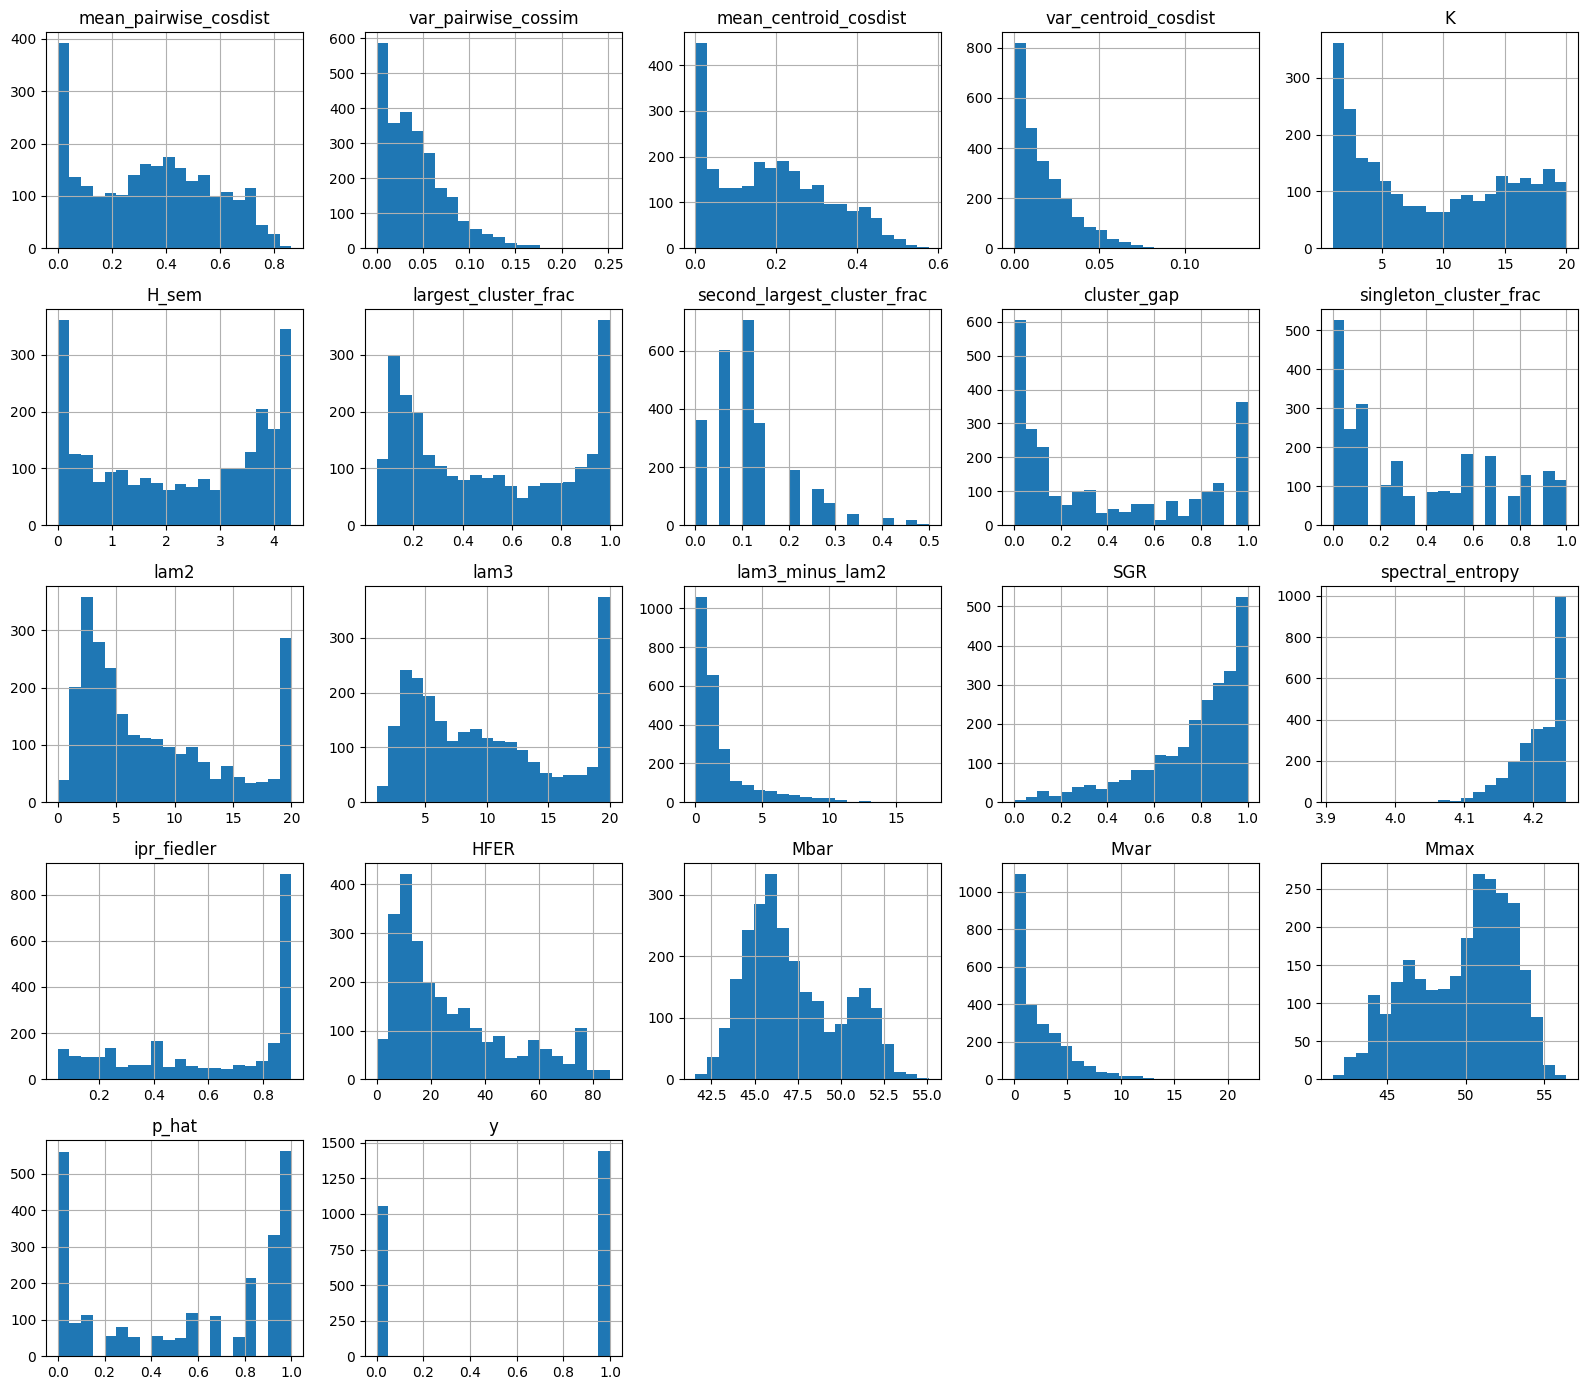

In [45]:
X.hist(figsize=(16, 14), bins=20)
plt.tight_layout()
plt.show()

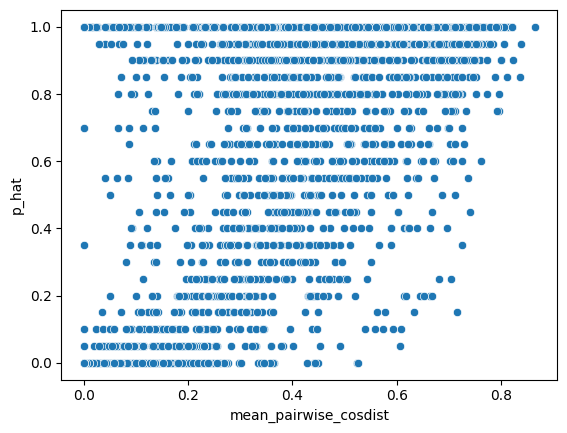

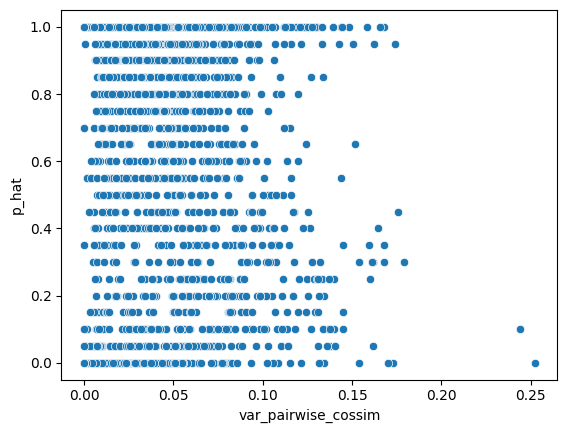

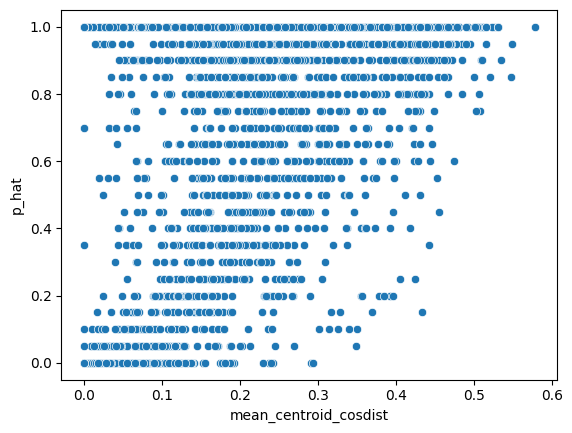

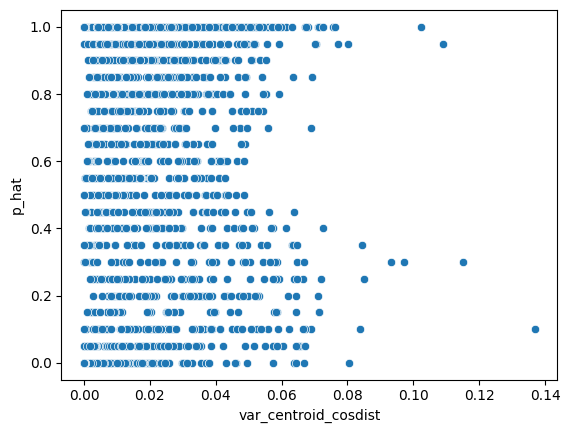

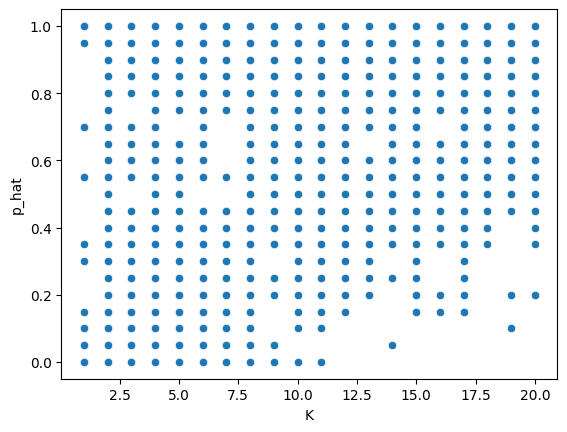

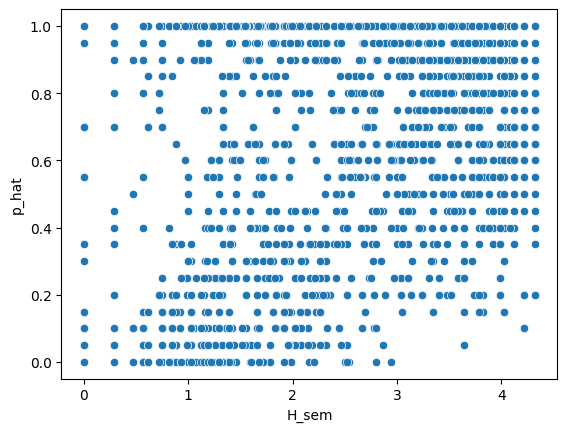

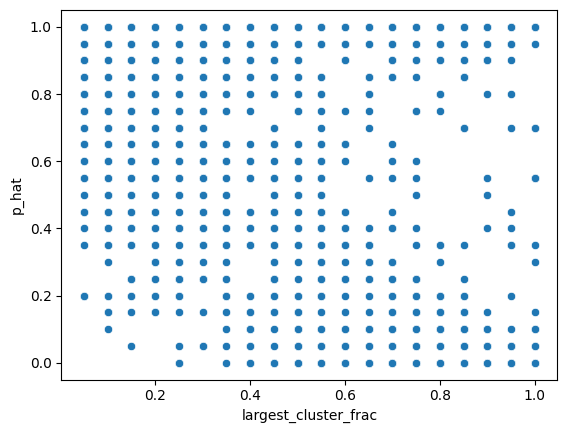

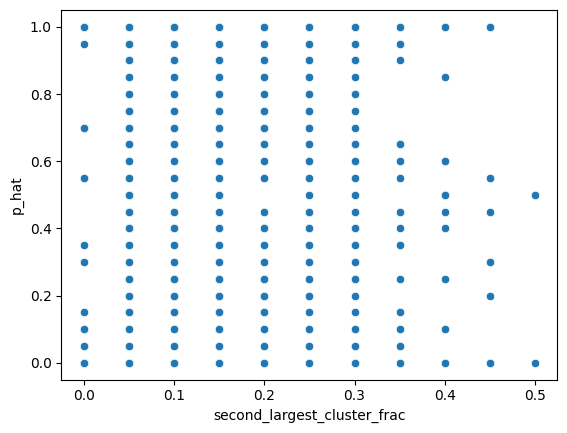

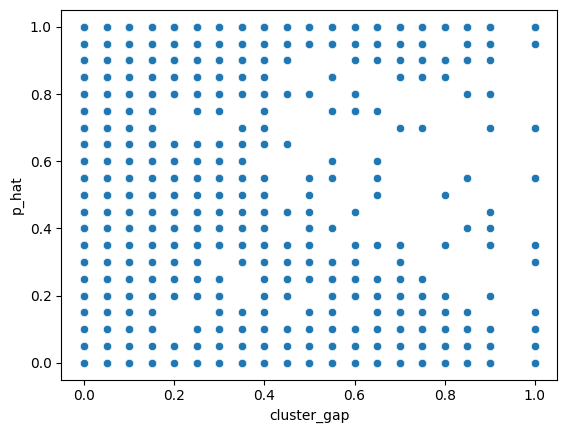

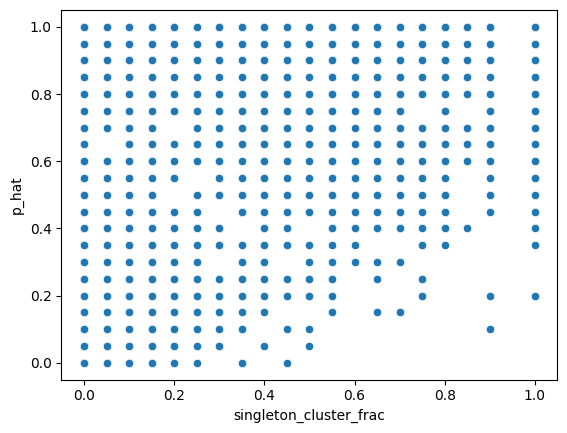

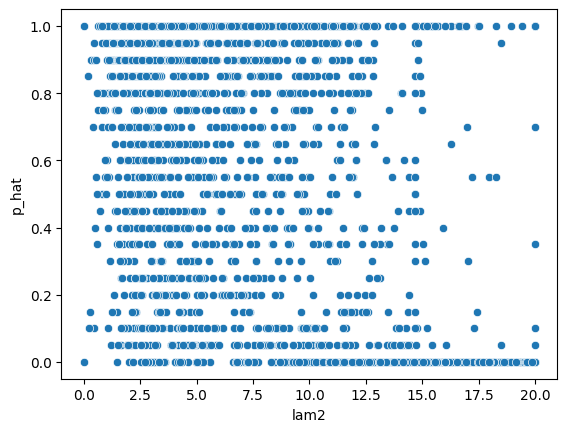

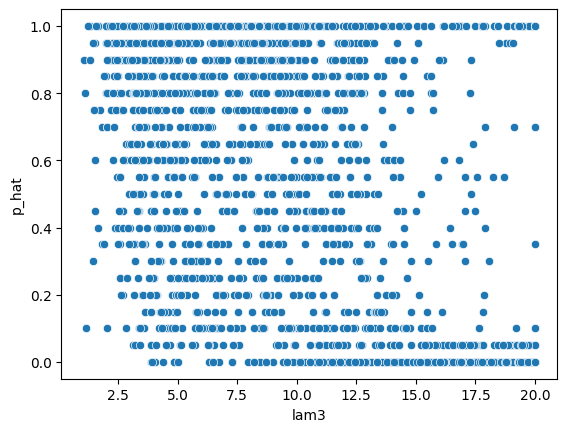

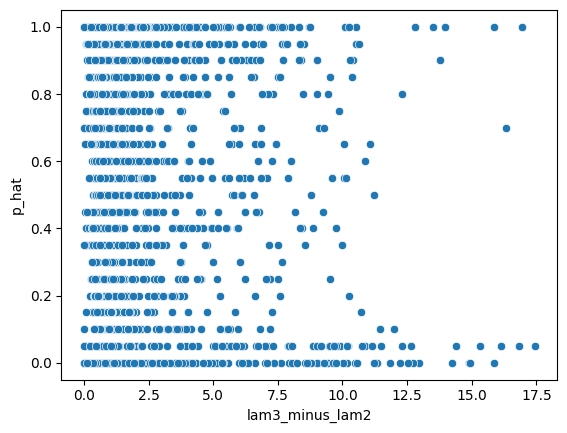

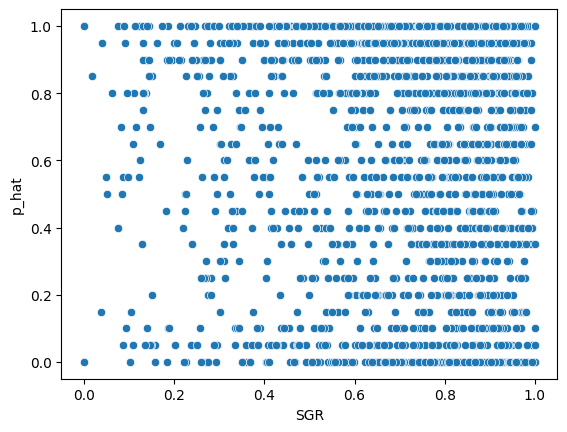

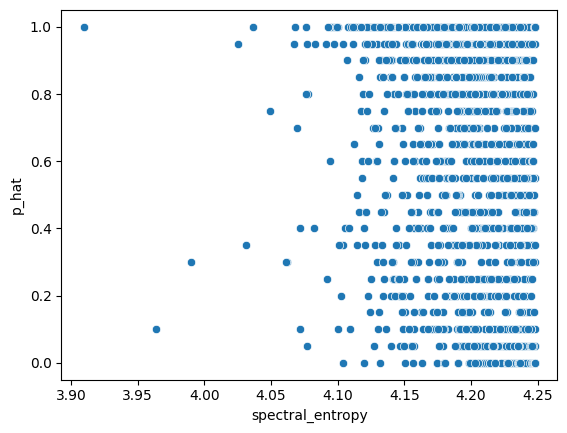

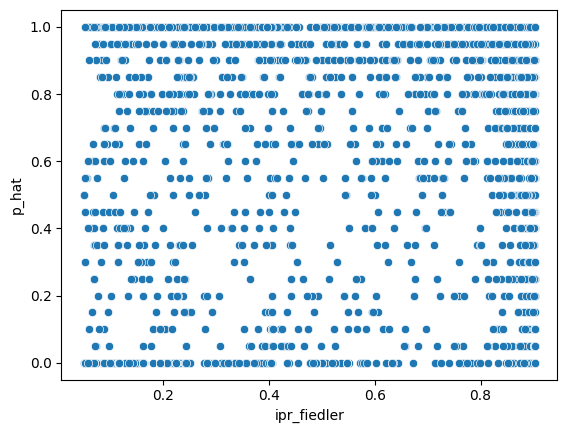

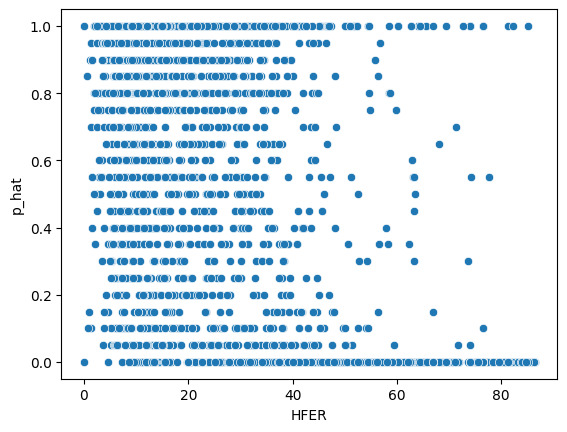

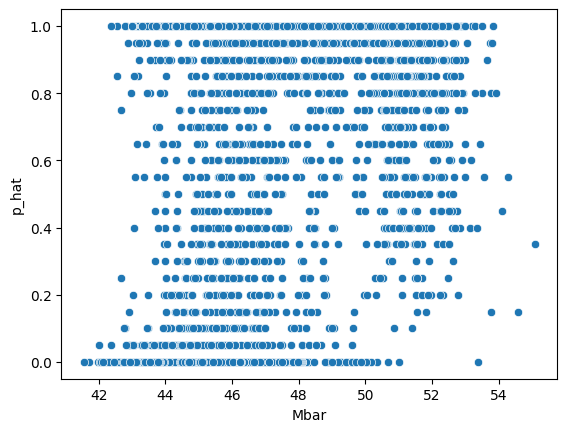

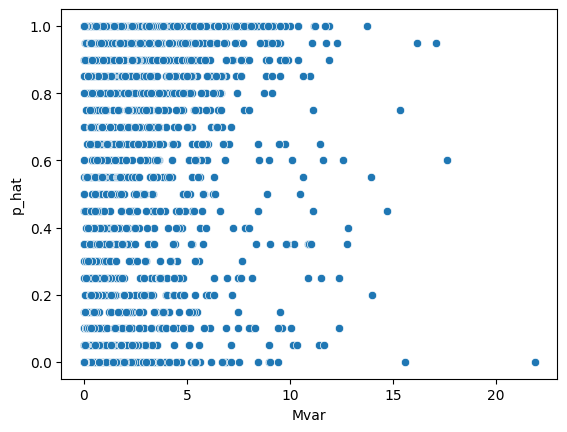

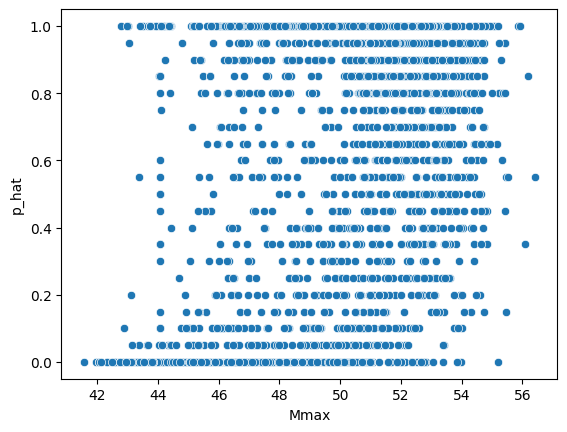

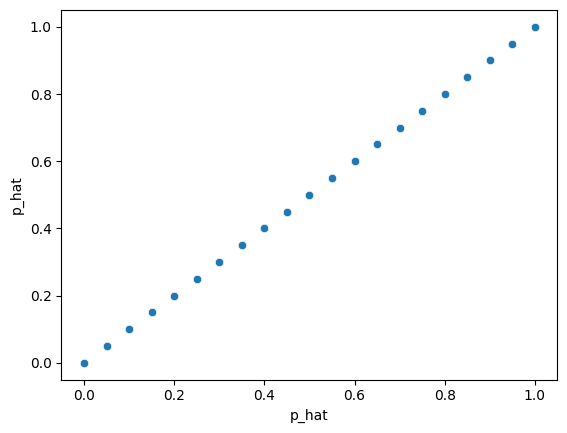

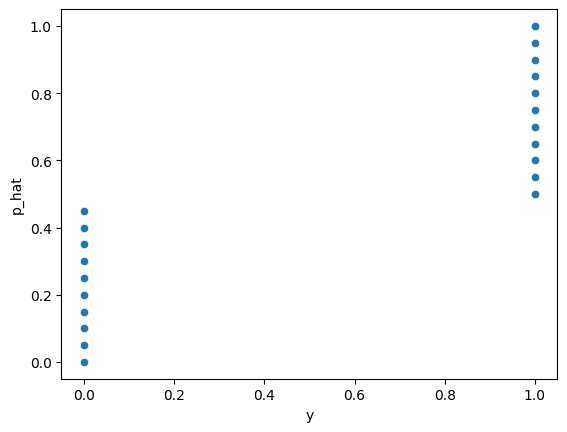

In [60]:
for col in X.drop(columns=X.columns[[0,1]]).columns.tolist():
    sns.scatterplot(data=X, x=col, y="p_hat")
    plt.show()

<Axes: xlabel='dataset', ylabel='p_hat'>

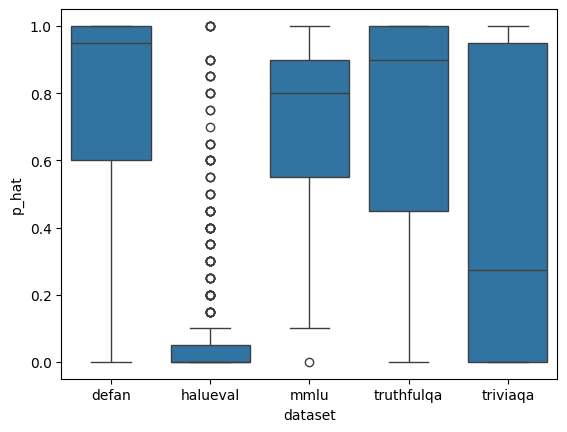

In [58]:
sns.boxplot(data=X, x="dataset", y="p_hat")

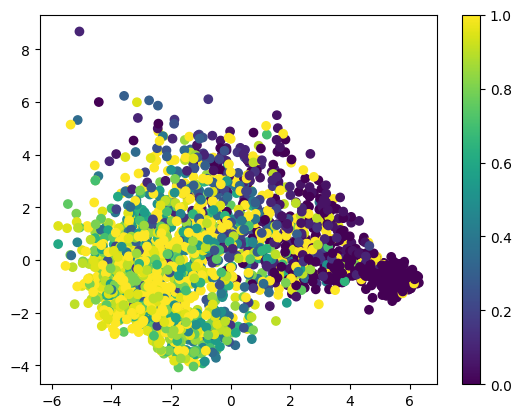

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = X.drop(columns=["dataset","q_id","p_hat","y"])

X_scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.scatter(Z[:,0], Z[:,1], c=X["p_hat"], cmap="viridis")
plt.colorbar()

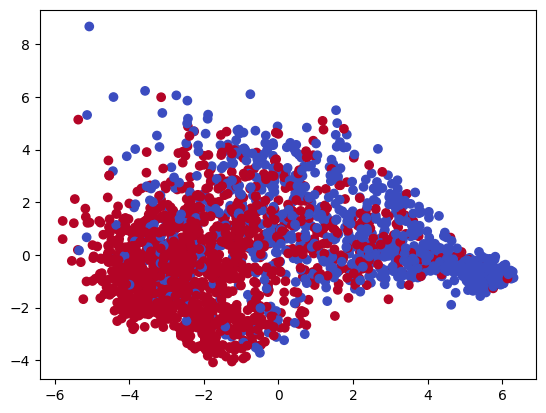

In [64]:
plt.scatter(Z[:,0], Z[:,1], c=X["y"], cmap="coolwarm")

In [67]:
X.to_csv("full_feature_matrix.csv")